# SETUP

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
label = 'SalePrice'

train = pd.read_csv('/kaggle/input/competitions/home-data-for-ml-course/train.csv')
test = pd.read_csv('/kaggle/input/competitions/home-data-for-ml-course/test.csv')

features = [
    "YearBuilt",
    "YearRemodAdd",
    "OverallQual",
    "OverallCond",
    "LotArea",
    "1stFlrSF",
    "2ndFlrSF",
    "GrLivArea",
    "TotRmsAbvGrd",
    "GarageCars",
    "GarageArea",
    "PoolArea"
]

train = train[features + [label]]
test = test[features]

# EDA

In [28]:
display(train.info())
display(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   YearBuilt     1460 non-null   int64
 1   YearRemodAdd  1460 non-null   int64
 2   OverallQual   1460 non-null   int64
 3   OverallCond   1460 non-null   int64
 4   LotArea       1460 non-null   int64
 5   1stFlrSF      1460 non-null   int64
 6   2ndFlrSF      1460 non-null   int64
 7   GrLivArea     1460 non-null   int64
 8   TotRmsAbvGrd  1460 non-null   int64
 9   GarageCars    1460 non-null   int64
 10  GarageArea    1460 non-null   int64
 11  PoolArea      1460 non-null   int64
 12  SalePrice     1460 non-null   int64
dtypes: int64(13)
memory usage: 148.4 KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   YearBuilt     1459 non-null   int64  
 1   YearRemodAdd  1459 non-null   int64  
 2   OverallQual   1459 non-null   int64  
 3   OverallCond   1459 non-null   int64  
 4   LotArea       1459 non-null   int64  
 5   1stFlrSF      1459 non-null   int64  
 6   2ndFlrSF      1459 non-null   int64  
 7   GrLivArea     1459 non-null   int64  
 8   TotRmsAbvGrd  1459 non-null   int64  
 9   GarageCars    1458 non-null   float64
 10  GarageArea    1458 non-null   float64
 11  PoolArea      1459 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 136.9 KB


None

In [29]:
display(train.head(5))
display(test.head(5))

,YearBuilt,YearRemodAdd,OverallQual,OverallCond,LotArea,1stFlrSF,2ndFlrSF,GrLivArea,TotRmsAbvGrd,GarageCars,GarageArea,PoolArea,SalePrice
0,2003,2003,7,5,8450,856,854,1710,8,2,548,0,208500
1,1976,1976,6,8,9600,1262,0,1262,6,2,460,0,181500
2,2001,2002,7,5,11250,920,866,1786,6,2,608,0,223500
3,1915,1970,7,5,9550,961,756,1717,7,3,642,0,140000
4,2000,2000,8,5,14260,1145,1053,2198,9,3,836,0,250000


,YearBuilt,YearRemodAdd,OverallQual,OverallCond,LotArea,1stFlrSF,2ndFlrSF,GrLivArea,TotRmsAbvGrd,GarageCars,GarageArea,PoolArea
0,1961,1961,5,6,11622,896,0,896,5,1.0,730.0,0
1,1958,1958,6,6,14267,1329,0,1329,6,1.0,312.0,0
2,1997,1998,5,5,13830,928,701,1629,6,2.0,482.0,0
3,1998,1998,6,6,9978,926,678,1604,7,2.0,470.0,0
4,1992,1992,8,5,5005,1280,0,1280,5,2.0,506.0,0


In [30]:
display(train.describe().T)
display(test.describe().T)

,count,mean,std,min,25%,50%,75%,max
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.0,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.0,1994.0,2004.00,2010.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.0,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.0,5.0,6.00,9.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.5,9478.5,11601.50,215245.0
1stFlrSF,1460.0,1162.626712,386.587738,334.0,882.0,1087.0,1391.25,4692.0
2ndFlrSF,1460.0,346.992466,436.528436,0.0,0.0,0.0,728.00,2065.0
GrLivArea,1460.0,1515.463699,525.480383,334.0,1129.5,1464.0,1776.75,5642.0
TotRmsAbvGrd,1460.0,6.517808,1.625393,2.0,5.0,6.0,7.00,14.0
GarageCars,1460.0,1.767123,0.747315,0.0,1.0,2.0,2.00,4.0


,count,mean,std,min,25%,50%,75%,max
YearBuilt,1459.0,1971.357779,30.390071,1879.0,1953.0,1973.0,2001.0,2010.0
YearRemodAdd,1459.0,1983.662783,21.130467,1950.0,1963.0,1992.0,2004.0,2010.0
OverallQual,1459.0,6.078821,1.436812,1.0,5.0,6.0,7.0,10.0
OverallCond,1459.0,5.553804,1.113740,1.0,5.0,5.0,6.0,9.0
LotArea,1459.0,9819.161069,4955.517327,1470.0,7391.0,9399.0,11517.5,56600.0
1stFlrSF,1459.0,1156.534613,398.165820,407.0,873.5,1079.0,1382.5,5095.0
2ndFlrSF,1459.0,325.967786,420.610226,0.0,0.0,0.0,676.0,1862.0
GrLivArea,1459.0,1486.045922,485.566099,407.0,1117.5,1432.0,1721.0,5095.0
TotRmsAbvGrd,1459.0,6.385195,1.508895,3.0,5.0,6.0,7.0,15.0
GarageCars,1458.0,1.766118,0.775945,0.0,1.0,2.0,2.0,5.0


array([[<Axes: title={'center': 'YearBuilt'}>,
        <Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>],
       [<Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'GrLivArea'}>],
       [<Axes: title={'center': 'TotRmsAbvGrd'}>,
        <Axes: title={'center': 'GarageCars'}>,
        <Axes: title={'center': 'GarageArea'}>,
        <Axes: title={'center': 'PoolArea'}>],
       [<Axes: title={'center': 'SalePrice'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

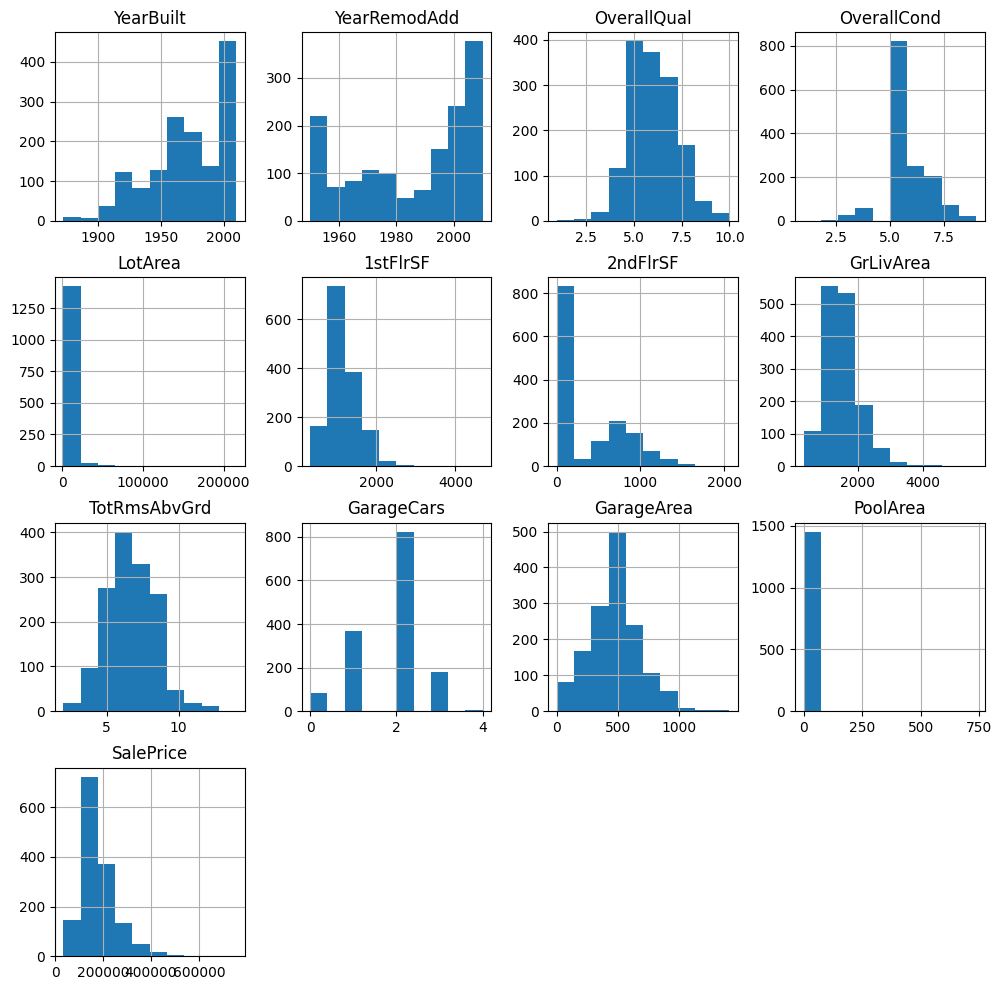

In [31]:
train.hist(figsize=(12, 12))

<Figure size 1600x1200 with 0 Axes>

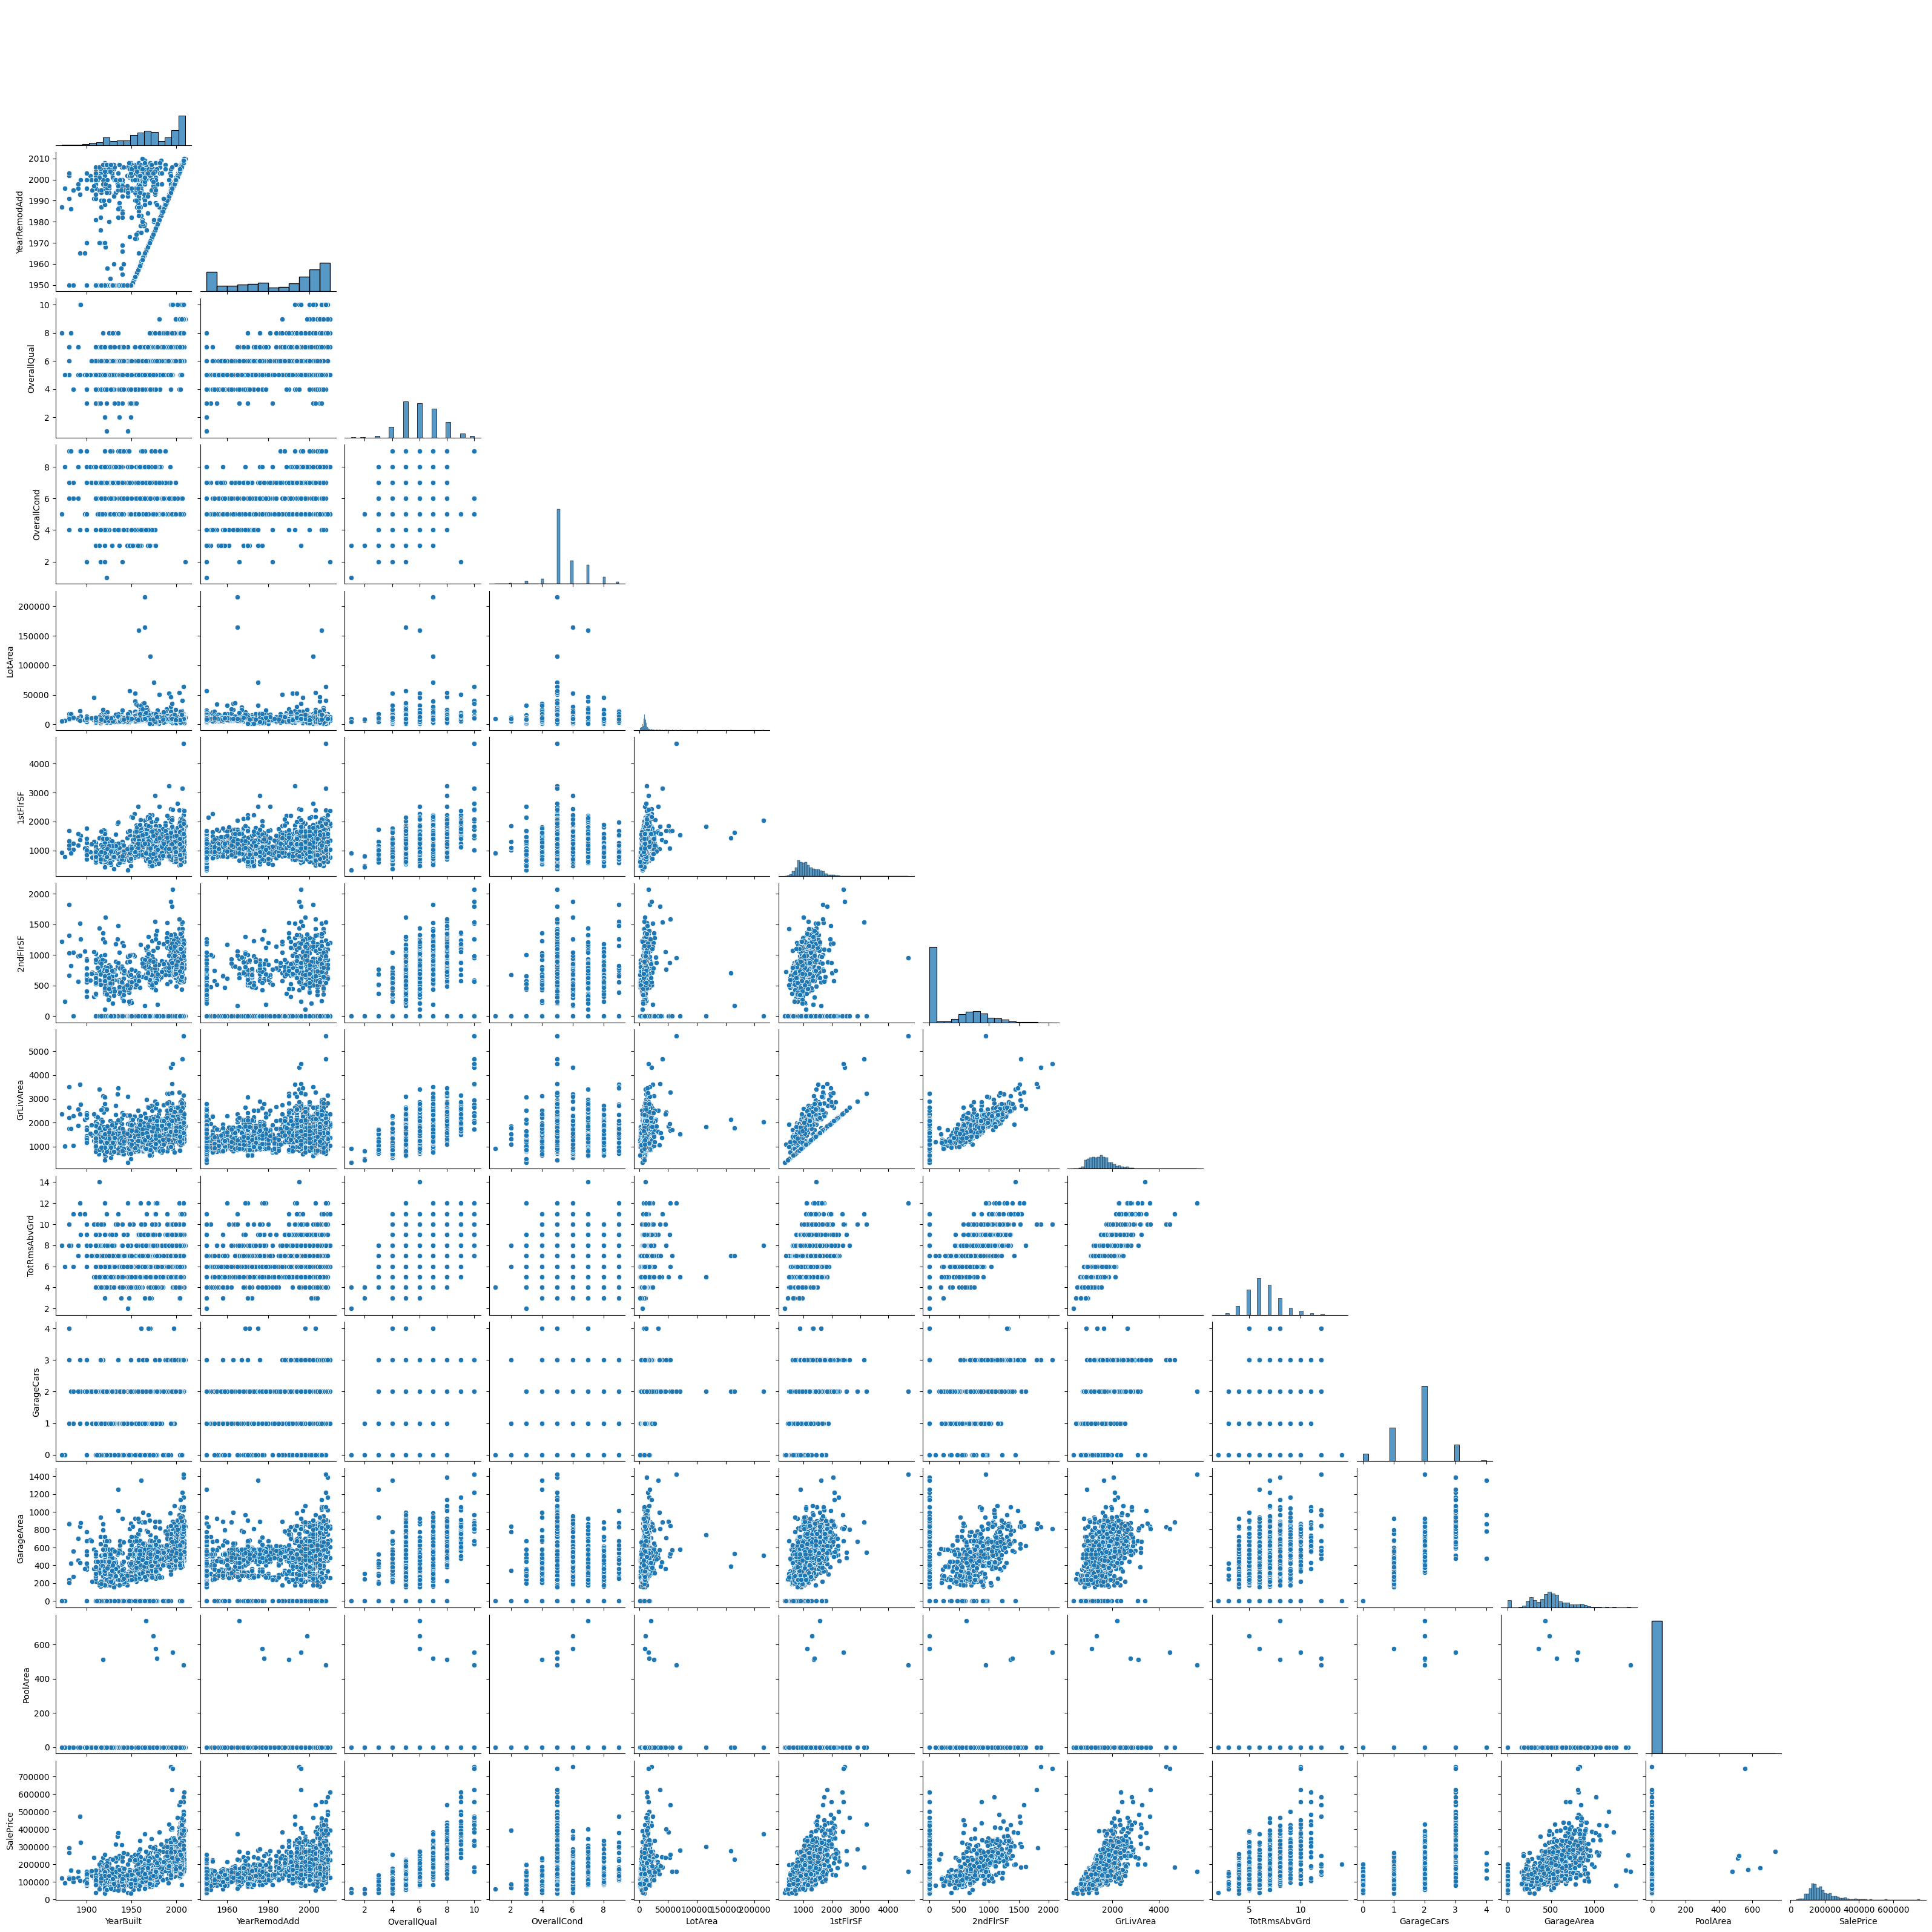

In [50]:
plt.figure(figsize=(16, 12))
sns.pairplot(train, corner=True, kind='scatter')
plt.show()

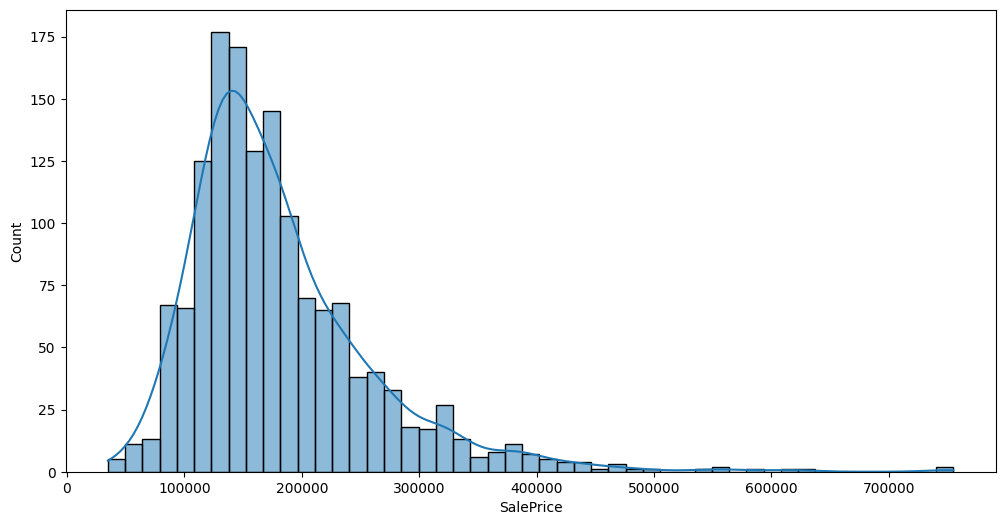

In [33]:
plt.figure(figsize=(12, 6))
sns.histplot(train[label], kde=True)
plt.show()

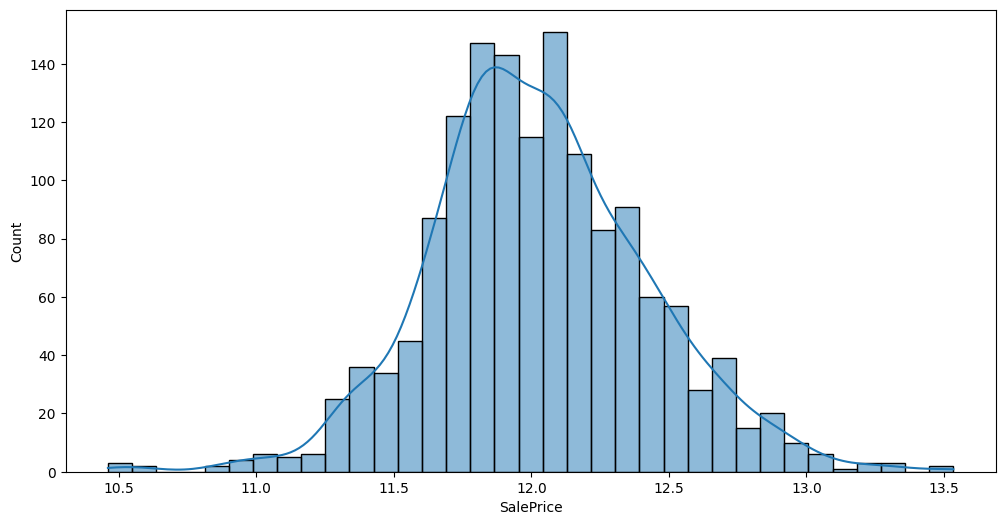

In [34]:
plt.figure(figsize=(12, 6))
sns.histplot(np.log1p(train[label]), kde=True)
plt.show()

# Data Preprocessing & Feature Engineering (if needed)

In [ ]:
# Do It Here!


# Modeling

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

X = train.drop(columns=[label])
y = train[label]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=13)

In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_val)

mae = mean_absolute_error(y_pred, y_val)
mse = mean_squared_error(y_pred, y_val)
print(f"MAE : {mae} ")
# print(f"MSE : {mse} ")
# print(f"RMSE : {np.sqrt(mse)} ")

MAE : 28564.16225600711 


In [39]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=13)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)

mae = mean_absolute_error(y_pred, y_val)
mse = mean_squared_error(y_pred, y_val)

print(f"MAE : {mae} ")
# print(f"MSE : {mse} ")
# print(f"RMSE : {np.sqrt(mse)} ")

MAE : 30345.591324200912 


In [40]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=13)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)

mae = mean_absolute_error(y_pred, y_val)
mse = mean_squared_error(y_pred, y_val)

print(f"MAE : {mae} ")
# print(f"MSE : {mse} ")
# print(f"RMSE : {np.sqrt(mse)} ")

MAE : 22801.00575342466 


In [42]:
from xgboost import XGBRegressor

model = XGBRegressor(random_state=13)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)

mae = mean_absolute_error(y_pred, y_val)
mse = mean_squared_error(y_pred, y_val)

print(f"MAE : {mae} ")
# print(f"MSE : {mse} ")
# print(f"RMSE : {np.sqrt(mse)} ")""

MAE : 22132.13671875 


# Fine Tuning (if wanted)

In [ ]:
# grid search
from sklearn.model_selection import GridSearchCV

# randomize search
from sklearn.model_selection import RandomizedSearchCV

# optuna
import optuna

# Predictions & make submission

In [45]:
# define final model
final_model = XGBRegressor(random_state=13)

# fit all the data
final_model.fit(X, y)

# make predictions for the test dataset
predictions = model.predict(test)

In [51]:
# make submission
submission = pd.read_csv('/kaggle/input/competitions/home-data-for-ml-course/sample_submission.csv')
submission[label] = predictions

In [52]:
submission.to_csv('submission.csv', index=False)